In [9]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt


In [10]:
def simulate_projectile(init_speed, launch_angle, g=9.81):
    angle_rad = math.radians(launch_angle)

    horizontal_distance = (init_speed**2 * math.sin(2 * angle_rad)) / g
    peak_height = (init_speed**2 * (math.sin(angle_rad)**2)) / (2 * g)

    return horizontal_distance, peak_height


In [11]:
records = []

num_runs = 1000

for _ in range(num_runs):
    speed = np.random.uniform(10, 100)
    angle = np.random.uniform(10, 90)

    true_range, max_height = simulate_projectile(speed, angle)

    measurement_noise = np.random.normal(0, 1.0)
    observed_range = true_range + measurement_noise

    records.append({
        "Initial_Speed": speed,
        "Launch_Angle": angle,
        "Theoretical_Range": true_range,
        "Measured_Range": observed_range
    })

sim_df = pd.DataFrame(records)
print("Preview of Simulation Data:")
sim_df.head()



Preview of Simulation Data:


,Initial_Speed,Launch_Angle,Theoretical_Range,Measured_Range
0,26.228649,49.146305,69.393391,67.398882
1,30.230539,88.728439,4.133564,5.010750
2,91.038873,68.916224,567.155296,567.501657
3,32.148681,16.379912,57.009842,57.061739
4,32.391216,76.320134,49.152155,48.408204


In [12]:
sim_df.to_csv("simulationData.csv", index=False)
print("Simulation data saved as simulationData.csv")



Simulation data saved as simulationData.csv


In [13]:
from google.colab import files

files.download("simulationData.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

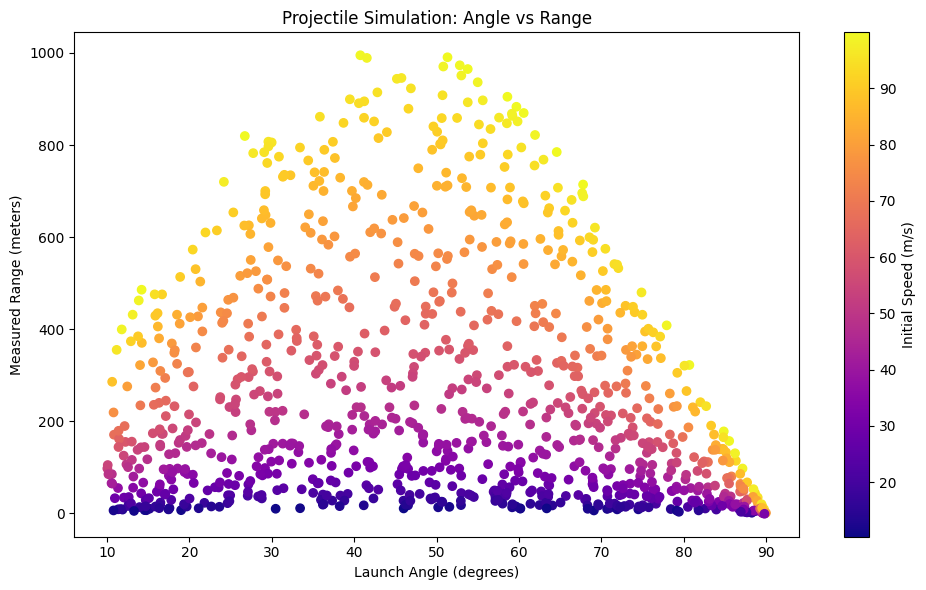

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(
    sim_df["Launch_Angle"],
    sim_df["Measured_Range"],
    c=sim_df["Initial_Speed"],
    cmap="plasma"
)

plt.xlabel("Launch Angle (degrees)")
plt.ylabel("Measured Range (meters)")
plt.title("Projectile Simulation: Angle vs Range")
plt.colorbar(label="Initial Speed (m/s)")
plt.tight_layout()

plt.savefig("simulation_plot.png")
plt.show()
